# Step 6. 결과 정리

Step 5 평가 결과(`data/cache/step5_*.parquet`, `outputs/feature_candidates.csv`)로 추천 변수 Top 20과 계열별 요약을 만든다. 서술형 요약은 `outputs/eda_report.md`에 있다.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src import plotting as P

pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 70)
P.setup()

S = pd.read_parquet(ROOT / "data" / "cache" / "step5_stock_eval.parquet")
TS = pd.read_parquet(ROOT / "data" / "cache" / "step5_market_eval.parquet")
cand = pd.read_csv(ROOT / "outputs" / "feature_candidates.csv").set_index("변수명")

## 1. 추천 등급 분포

In [2]:
g = cand.groupby(["계열", "추천 등급"]).size().unstack(fill_value=0)
g = g[[c for c in ["강력 추천", "검토", "제외"] if c in g.columns]]
g["합계"] = g.sum(axis=1)
g.sort_values("강력 추천", ascending=False)

추천 등급,강력 추천,검토,제외,합계
계열,,,,
하방 특성,7,7,2,16
수급,5,12,7,24
가격 위치,3,1,1,5
공매도·대차,2,2,2,6
거래·유동성,2,6,2,10
변동성,2,8,0,10
시장 대비,1,4,0,5
신용,1,0,3,4
업종,1,2,1,4


## 2. 추천 변수 Top 20

선정 규칙: '강력 추천' 등급(묶음 대표이고 |IC IR| ≥ 0.5, 겹치지 않는 표본 |t| ≥ 4, 월별 부호 일치 ≥ 80%, 전·후반 부호 동일)을 |IC IR| 순으로 20개 뽑는다.

In [3]:
strong = S[S.grade == "강력 추천"]
top = strong.reindex(strong.ic_ir.abs().sort_values(ascending=False).index)
top20 = top.head(20).copy()
top20.insert(0, "순위", range(1, 21))
top20["계산식"] = cand.loc[top20.index, "계산식"]
top20["방향"] = np.where(top20.mean_ic < 0, "클수록 위험", "클수록 안전")
cols = ["순위", "family", "방향", "mean_ic", "ic_ir", "t_nonoverlap", "partial_ic_ir", "ic_first", "ic_second", "shape", "계산식"]
top20[cols].round(3)

,순위,family,방향,mean_ic,ic_ir,t_nonoverlap,partial_ic_ir,ic_first,ic_second,shape,계산식
gk_5,1,변동성,클수록 위험,-0.326,-2.074,-21.204,-1.625,-0.332,-0.320,단조 감소,"Garman-Klass: sqrt(mean(0.5 ln(H/L)^2 - (2ln2-1) ln(C/O)^2)), 5일"
range_1,2,캔들,클수록 위험,-0.273,-1.915,-20.186,-1.229,-0.272,-0.273,단조 감소,(High - Low) / Close
vol_5,3,변동성,클수록 위험,-0.244,-1.621,-17.378,-0.755,-0.250,-0.237,단조 감소,std(log수익률[t-4..t])
dist_low_60,4,가격 위치,클수록 위험,-0.254,-1.573,-15.471,-0.817,-0.237,-0.270,단조 감소,Close / min(Low[t-59..t]) - 1
ind_vol_20,5,업종,클수록 위험,-0.227,-1.353,-13.640,-0.444,-0.243,-0.211,단조 감소,같은 날 같은 업종 구성종목의 vol_20 평균
min_intra_drop_20,6,하방 특성,클수록 안전,0.232,1.331,13.663,0.119,0.244,0.221,단조 증가,"min(Low / 전일 Close - 1), 20일"
skew_60,7,하방 특성,클수록 위험,-0.118,-1.285,-12.075,-0.572,-0.116,-0.121,단조 감소,"왜도(log수익률, 60일)"
turnover_20,8,거래·유동성,클수록 위험,-0.216,-1.237,-11.192,-0.385,-0.230,-0.202,단조 감소,"mean(원 거래량 / 상장주식수), 20일"
n_down3_60,9,하방 특성,클수록 위험,-0.254,-1.235,-12.790,-0.496,-0.287,-0.220,단조 감소,최근 60일 중 일간 수익률 ≤ -3%인 날의 비율
lend_days_20,10,공매도·대차,클수록 안전,0.170,1.119,10.341,0.222,0.169,0.170,단조 증가,대차잔고 수량 / 20일 평균 통합 거래량


In [4]:
print("강력 추천 중 Top 20 밖:", top.index[20:].tolist())

강력 추천 중 Top 20 밖: ['past_mdd_5', 'log_value_20', 'foreign_hold', 'prog_nonarb_net_20', 'indiv_net_20']


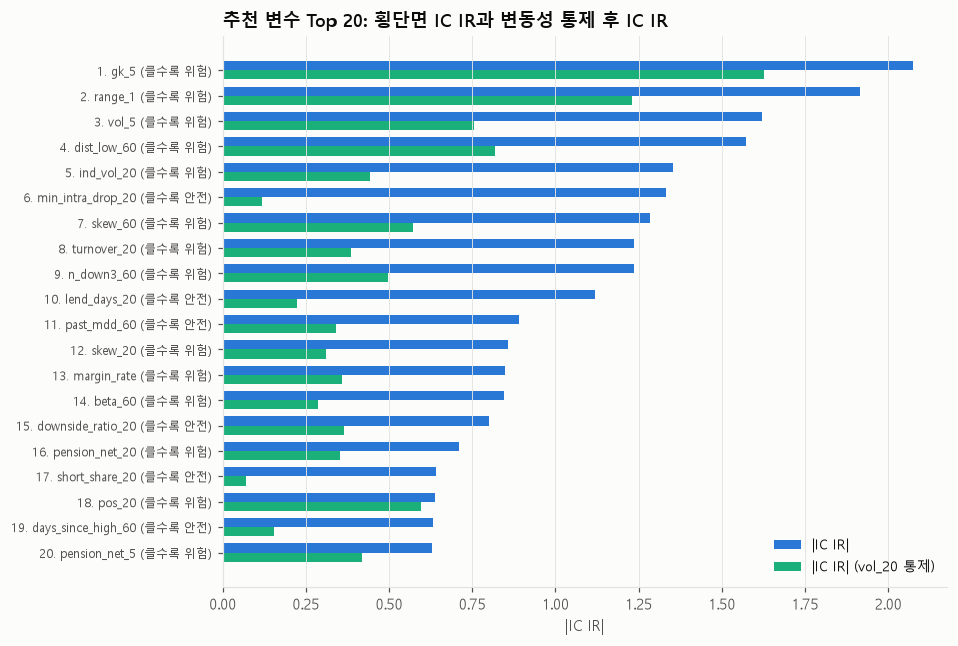

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 6.5))
y = np.arange(len(top20))[::-1]
ax.barh(y + 0.18, top20.ic_ir.abs(), height=0.36, color=P.SERIES[0], label="|IC IR|")
ax.barh(y - 0.18, top20.partial_ic_ir.abs().fillna(0), height=0.36, color=P.SERIES[2], label="|IC IR| (vol_20 통제)")
ax.set_yticks(y, [f"{i}. {n} ({d})" for i, n, d in zip(top20.순위, top20.index, top20.방향)], fontsize=8)
ax.set_xlabel("|IC IR|")
ax.set_title("추천 변수 Top 20: 횡단면 IC IR과 변동성 통제 후 IC IR")
ax.legend(frameon=False, fontsize=9, loc="lower right")
ax.grid(axis="y", visible=False)
P.save(fig, "07_top20")
plt.show()

## 3. 시장 변수 (날짜 공통) — 강력 추천 없음

In [6]:
TS[TS.grade != "제외"].sort_values("ts_rho_nonoverlap", key=abs, ascending=False)[
    ["family", "ts_rho_nonoverlap", "p_nonoverlap", "ts_first", "ts_second", "grade"]].round(3)

,family,ts_rho_nonoverlap,p_nonoverlap,ts_first,ts_second,grade
cs_dispersion_1,시장,-0.217,0.024,-0.034,-0.335,검토
mkt_ret_20,시장,-0.192,0.046,-0.193,-0.390,검토
mkt_institution_net_20,시장 수급,-0.184,0.057,-0.161,-0.023,검토
mkt_ret_60,시장,-0.179,0.064,-0.122,-0.542,검토
breadth_adv_5,시장,0.154,0.112,0.200,0.113,검토


## 4. 눈에 띄는 제외·약한 변수

In [7]:
weak = S[S.grade == "제외"].sort_values("ic_ir", key=abs)
weak[["family", "mean_ic", "ic_ir", "t_nonoverlap", "ic_first", "ic_second"]].round(3)

,family,mean_ic,ic_ir,t_nonoverlap,ic_first,ic_second
prog_arb_net_5,수급,-0.002,-0.008,0.092,-0.053,0.049
prog_arb_net_1,수급,-0.003,-0.014,-0.182,-0.027,0.020
fininv_net_20,수급,-0.002,-0.016,-0.687,-0.005,0.001
lower_shadow_5,캔들,0.002,0.020,0.449,0.020,-0.015
fininv_net_5,수급,-0.005,-0.039,-0.023,-0.002,-0.009
log_mcap,거래·유동성,-0.006,-0.040,-0.761,0.008,-0.021
fininv_net_1,수급,0.006,0.042,-0.288,0.009,0.003
lend_chg_5,공매도·대차,-0.004,-0.043,0.151,-0.010,0.003
kurt_60,하방 특성,-0.004,-0.050,-0.730,0.002,-0.010
ind_foreign_net_5,업종,-0.010,-0.082,-0.931,-0.012,-0.008
